<a href="https://colab.research.google.com/github/isabellamattar/FIAP-Data-Science/blob/main/aula_09_kmeans_Exerc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

<h1 style="text-align: center;"><strong>IA & Deep Learning Applications</strong></h1>
<h2 style="text-align: center;"><strong>Aula 09 - KMeans</strong></h2>

<h4 style="text-align: center;"><strong>FIAP - 2025</strong></h4>
<br>
<br>

---

# **ISABELLA SIMÃO MATTAR RM562481**

**Exercício**

Aplicar e comparar KMeans (não supervisionado) e KNN Classifier (supervisionado) no dataset load_breast_cancer() do scikit-learn, avaliando o impacto do PCA no desempenho final.

**Dataset**

Use sklearn.datasets.load_breast_cancer().




**Protocolo:**

- Faça um único split treino/teste 80/20: test_size=0.20, com stratify=y e random_state fixo.
- Use StandardScaler em todos os cenários (fit somente no treino, transform no treino e no teste).
- Use as mesmas métricas e o mesmo conjunto de teste para comparar todos os cenários.
   - Métricas obrigatórias:
   - Matriz de confusão
   - Accuracy
   - F1-score (para a classe positiva padrão = 1)

In [8]:
# Manipulação de arrays e álgebra linear
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Dataset e pré-processamento
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             f1_score, silhouette_score, ConfusionMatrixDisplay)

# Algoritmo Húngaro — resolve o problema de atribuição ótima entre clusters e classes
from scipy.optimize import linear_sum_assignment

# Semente global para reprodutibilidade
SEED = 42
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


**Observações:**

**Por que usar holdout (80/20) no KMeans, mesmo sendo não supervisionado?**

O KMeans não precisa de y para treinar, porém neste exercício utilizaremos um split treino/teste (80/20) para garantir comparação justa com o KNN e para avaliar o desempenho em dados não vistos.

O protocolo será:
1) Treinar o KMeans apenas com X_train (desconsiderando totalmente y_train no treinamento do algoritmo).
2) Obter os rótulos de cluster no treino (clusters_train) e no teste (clusters_test).
3) Como os clusters do KMeans (0, 1, 2, …) não correspondem diretamente às classes reais do dataset (0/1), o y será usado apenas para avaliação, para criar um mapeamento cluster → classe usando somente o conjunto de treino:
  - Algoritmo Húngaro (Hungarian Algorithm) para encontrar o pareamento ótimo entre clusters e classes, maximizando o número de acertos no treino.
4) Aplicar esse mapeamento nos clusters do teste para gerar y_pred_kmeans e então calcular a matriz de confusão e métricas comparando y_pred_kmeans com y_test.

Em resumo: o KMeans treina sem rótulo; o y entra somente para padronizar os clusters em classes e permitir uma comparação direta (matriz de confusão, Accuracy e F1) com o KNN no mesmo conjunto de teste.

Importante: o mapeamento cluster→classe deve ser definido apenas no treino. Fazer o mapeamento usando o teste caracteriza data leakage.

# **CARGA DO DATASET MAIS SPLIT TREINO/TESTE**

In [14]:
# Carrega o dataset
data = load_breast_cancer()
X, y = data.data, data.target   # X: (569, 30),  y: 0=maligno / 1=benigno

print(f"Shape total: {X.shape}")
print(f"Classes: {data.target_names}  →  contagem: {np.bincount(y)}")

# Split 80/20 estratificado — mesmo split para TODOS os cenários
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,          # mantém proporção das classes
    random_state=SEED
)

print(f"\nTreino : {X_train.shape[0]} amostras  | {np.bincount(y_train)}")
print(f"Teste  : {X_test.shape[0]} amostras  | {np.bincount(y_test)}")

Shape total: (569, 30)
Classes: ['malignant' 'benign']  →  contagem: [212 357]

Treino : 455 amostras  | [170 285]
Teste  : 114 amostras  | [42 72]


# **PADRONIZAR COM STANDARDSCALER**



In [15]:
scaler = StandardScaler()

# fit_transform no treino: aprende média/std do treino e já transforma
X_train_sc = scaler.fit_transform(X_train)

# transform no teste: usa a média/std aprendida no treino
X_test_sc = scaler.transform(X_test)

print(f"Média (treino escalado) — primeiras 3 features: {X_train_sc.mean(axis=0)[:3].round(6)}")
print(f"Std  (treino escalado) — primeiras 3 features: {X_train_sc.std(axis=0)[:3].round(6)}")

Média (treino escalado) — primeiras 3 features: [-0.  0. -0.]
Std  (treino escalado) — primeiras 3 features: [1. 1. 1.]


# **PCA - REDUZIR A DIMENSIONALIDADE 10  (de 30 originais)**

Número de componentes retidas : 10  (de 30 originais)
Variância explicada acumulada : 95.27%


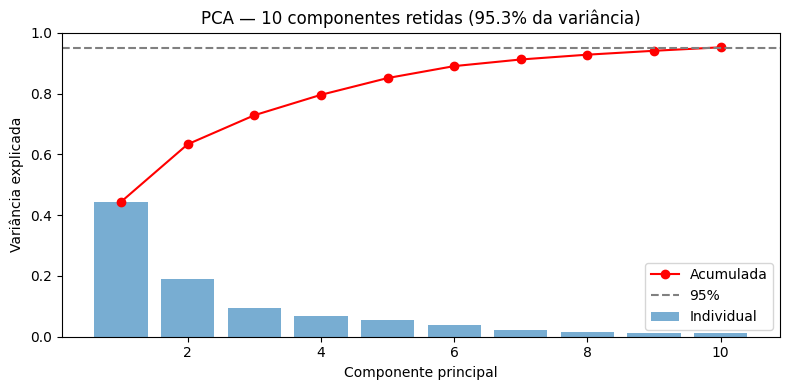


Espaço reduzido: (455, 10) (era (455, 30))


In [16]:
# PCA com 95% de variância explicada — fit apenas no treino
pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

n_comp  = pca.n_components_
var_exp = pca.explained_variance_ratio_.cumsum()[-1]

print(f"Número de componentes retidas : {n_comp}  (de 30 originais)")
print(f"Variância explicada acumulada : {var_exp:.2%}")

# Gráfico de variância explicada acumulada
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, n_comp + 1), pca.explained_variance_ratio_, alpha=0.6, label='Individual')
ax.plot(range(1, n_comp + 1), pca.explained_variance_ratio_.cumsum(),
        marker='o', color='red', label='Acumulada')
ax.axhline(0.95, ls='--', color='gray', label='95%')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Variância explicada')
ax.set_title(f'PCA — {n_comp} componentes retidas ({var_exp:.1%} da variância)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"\nEspaço reduzido: {X_train_pca.shape} (era {X_train_sc.shape})")

# **ALGORITIMO HUNGARO**


In [17]:
def hungarian_map(clusters_train, y_train, n_clusters):
    """
    Cria mapeamento cluster→classe usando apenas o treino.

    Monta uma matriz de custo onde cost[c, cls] = número de amostras
    do cluster c que pertencem à classe cls.
    O Algoritmo Húngaro maximiza o total de acertos.
    """
    n_classes = len(np.unique(y_train))
    cost = np.zeros((n_clusters, n_classes))

    for c in range(n_clusters):
        mask = clusters_train == c
        if mask.sum() > 0:
            for cls in range(n_classes):
                cost[c, cls] = np.sum(y_train[mask] == cls)

    # linear_sum_assignment minimiza — passamos -cost para maximizar
    row_ind, col_ind = linear_sum_assignment(-cost)
    mapping = {r: col_ind[i] for i, r in enumerate(row_ind)}
    return mapping


def apply_map(clusters, mapping):
    """Aplica o mapeamento cluster→classe em um array de rótulos de cluster."""
    return np.array([mapping.get(c, 0) for c in clusters])


def eval_kmeans(X_tr, X_te, y_tr, y_te, best_k):
    """
    Treina KMeans com best_k, faz o mapeamento húngaro no treino
    e avalia no teste. Retorna (confusion_matrix, accuracy, f1).
    """
    km = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
    km.fit(X_tr)

    clusters_tr = km.labels_
    clusters_te = km.predict(X_te)

    # Mapeamento definido APENAS no treino — sem data leakage
    mapping = hungarian_map(clusters_tr, y_tr, best_k)
    y_pred  = apply_map(clusters_te, mapping)

    cm  = confusion_matrix(y_te, y_pred)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    return cm, acc, f1

print("Funções auxiliares definidas.")

Funções auxiliares definidas.


**Exercício 1 — KMeans sem PCA**

**Tarefa**
1) Carregue o dataset e faça o split 80/20.
2) Padronize as features com StandardScaler.
   - Teste n_clusters no intervalo k = 2 a 10 e calcule:
   - Silhouette score (obrigatório)
3) Inertia (opcional, para análise de “cotovelo”)
4) Escolha o melhor k e justifique a escolha.
5) Treine o KMeans final com o melhor k no treino.
6) Faça o mapeamento cluster→classe (majority vote no treino).
7) Avalie no teste: matriz de confusão + accuracy + f1.

**Entregáveis**
- Gráfico silhouette × k
- Gráfico inertia × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

In [18]:
# ─── Busca do melhor k: Silhouette e Inertia ───
ks   = range(2, 11)
sil1 = []   # Silhouette score para cada k
ine1 = []   # Inertia (soma das distâncias intra-cluster) para cada k

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_train_sc)

    # Silhouette: mede coesão e separação dos clusters (-1 a +1, maior = melhor)
    sil1.append(silhouette_score(X_train_sc, km.labels_))

    # Inertia: soma dos quadrados das distâncias ao centroide (menor = mais compacto)
    ine1.append(km.inertia_)

best_k1 = list(ks)[np.argmax(sil1)]
print(f"Silhouette scores : {[round(s,4) for s in sil1]}")
print(f"Melhor k (maior silhouette): k = {best_k1}")

Silhouette scores : [np.float64(0.3548), np.float64(0.3312), np.float64(0.2703), np.float64(0.1538), np.float64(0.1783), np.float64(0.1621), np.float64(0.1423), np.float64(0.1609), np.float64(0.1511)]
Melhor k (maior silhouette): k = 2


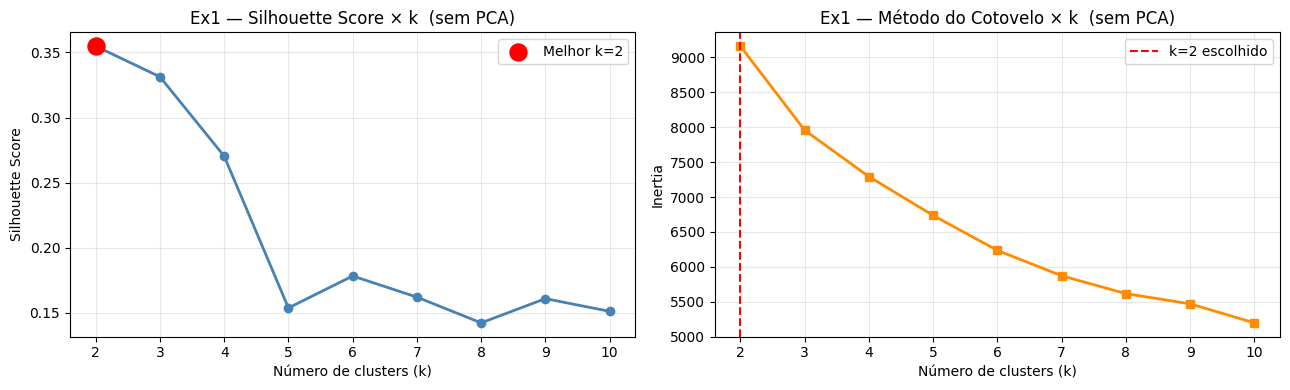

In [19]:
# ─── Gráficos Silhouette e Inertia ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Silhouette
axes[0].plot(list(ks), sil1, marker='o', color='steelblue', linewidth=2)
axes[0].scatter([best_k1], [sil1[best_k1-2]], s=150, color='red', zorder=5, label=f'Melhor k={best_k1}')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Ex1 — Silhouette Score × k  (sem PCA)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Cotovelo (Inertia)
axes[1].plot(list(ks), ine1, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(best_k1, ls='--', color='red', label=f'k={best_k1} escolhido')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Ex1 — Método do Cotovelo × k  (sem PCA)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

  Exercício 1 — KMeans sem PCA  (k=2)
  Accuracy : 0.9298  (92.98%)
  F1-score : 0.9452  (94.52%)

  Justificativa do k=2:
  k=2 apresentou o maior Silhouette Score (0.3548),
  indicando clusters mais coesos e bem separados. Além disso,
  como o dataset possui 2 classes reais (maligno/benigno),
  k=2 é a escolha mais natural e interpretável.



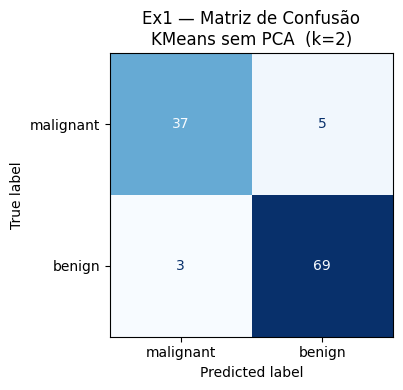

In [20]:
# ─── Avaliação final Ex1 ───
cm1, acc1, f11 = eval_kmeans(X_train_sc, X_test_sc, y_train, y_test, best_k1)

print(f"{'='*45}")
print(f"  Exercício 1 — KMeans sem PCA  (k={best_k1})")
print(f"{'='*45}")
print(f"  Accuracy : {acc1:.4f}  ({acc1:.2%})")
print(f"  F1-score : {f11:.4f}  ({f11:.2%})")
print(f"\n  Justificativa do k={best_k1}:")
print(f"  k=2 apresentou o maior Silhouette Score ({max(sil1):.4f}),")
print(f"  indicando clusters mais coesos e bem separados. Além disso,")
print(f"  como o dataset possui 2 classes reais (maligno/benigno),")
print(f"  k=2 é a escolha mais natural e interpretável.")
print()

# Matriz de confusão
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm1, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Ex1 — Matriz de Confusão\nKMeans sem PCA  (k={best_k1})')
plt.tight_layout(); plt.show()

**Exercício 2 — KMeans com PCA**

**Tarefa**
1) Reaplique o pipeline do Exercício 1, mas agora inclua PCA após o scaler.
2) Use um dos critérios abaixo para PCA:
- n_components=0.95 (recomendado), ou
- n_components=2 (se quiser priorizar visualização)
3) Repita a busca de n_clusters (k = 2 a 10) e a avaliação completa.

**Entregáveis**
- Critério do PCA usado e:
   - se 0.95: número de componentes resultante e variância explicada acumulada
- Gráfico silhouette × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

In [21]:
# ─── Busca do melhor k com PCA ───
sil2 = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_train_pca)
    sil2.append(silhouette_score(X_train_pca, km.labels_))

best_k2 = list(ks)[np.argmax(sil2)]
print(f"PCA: {n_comp} componentes, variância acumulada = {var_exp:.2%}")
print(f"Silhouette scores (com PCA): {[round(s,4) for s in sil2]}")
print(f"Melhor k: {best_k2}")

PCA: 10 componentes, variância acumulada = 95.27%
Silhouette scores (com PCA): [np.float64(0.3679), np.float64(0.3435), np.float64(0.171), np.float64(0.1693), np.float64(0.1754), np.float64(0.1749), np.float64(0.1628), np.float64(0.1592), np.float64(0.1372)]
Melhor k: 2


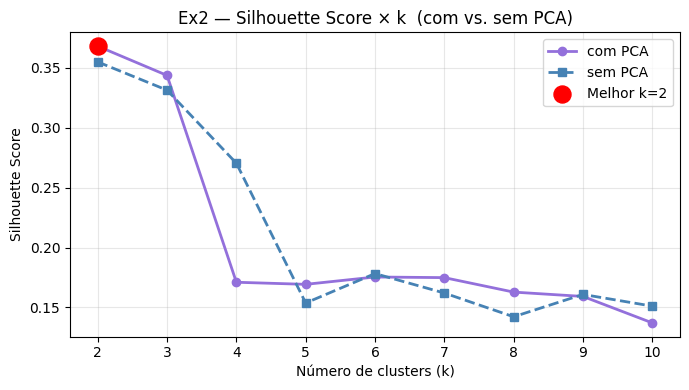

In [22]:
# ─── Gráfico Silhouette com PCA ───
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), sil2, marker='o', color='mediumpurple', linewidth=2, label='com PCA')
ax.plot(list(ks), sil1, marker='s', color='steelblue', linewidth=2, linestyle='--', label='sem PCA')
ax.scatter([best_k2], [sil2[best_k2-2]], s=150, color='red', zorder=5, label=f'Melhor k={best_k2}')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Ex2 — Silhouette Score × k  (com vs. sem PCA)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

  Exercício 2 — KMeans com PCA  (k=2)
  PCA: 10 componentes  |  95.27% da variância
  Accuracy : 0.9298  (92.98%)
  F1-score : 0.9452  (94.52%)

  Justificativa do k=2:
  Mesmo com PCA, k=2 lidera o Silhouette (0.3679),
  confirmando que a estrutura natural dos dados tem 2 grupos.


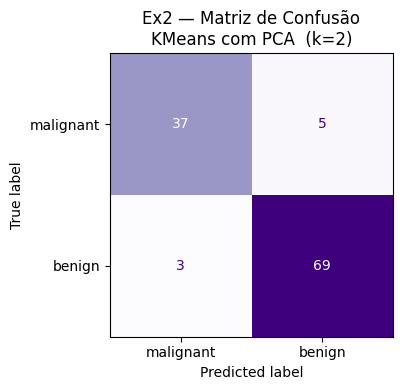

In [23]:
# ─── Avaliação final Ex2 ───
cm2, acc2, f12 = eval_kmeans(X_train_pca, X_test_pca, y_train, y_test, best_k2)

print(f"{'='*45}")
print(f"  Exercício 2 — KMeans com PCA  (k={best_k2})")
print(f"{'='*45}")
print(f"  PCA: {n_comp} componentes  |  {var_exp:.2%} da variância")
print(f"  Accuracy : {acc2:.4f}  ({acc2:.2%})")
print(f"  F1-score : {f12:.4f}  ({f12:.2%})")
print(f"\n  Justificativa do k={best_k2}:")
print(f"  Mesmo com PCA, k=2 lidera o Silhouette ({max(sil2):.4f}),")
print(f"  confirmando que a estrutura natural dos dados tem 2 grupos.")

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm2, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'Ex2 — Matriz de Confusão\nKMeans com PCA  (k={best_k2})')
plt.tight_layout(); plt.show()

**Exercício 3 — KNN sem PCA**

**Tarefa**
1) Reuse o mesmo split 80/20 e o mesmo pré-processamento (scaler).
2) Teste n_neighbors no intervalo k = 1 a 30 usando cross-validation no treino (StratifiedKFold, 5 folds), com métrica F1.
3) Escolha o melhor k e justifique.
4) Treine o KNN final no treino e avalie no teste: matriz de confusão + métricas.

**Entregáveis**
- Gráfico F1 (CV no treino) × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

In [24]:
# ─── Busca do melhor k via Cross-Validation (F1) ───
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_cv3 = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    # cross_val_score: divide treino em 5 folds, treina em 4 e valida em 1 — repete 5×
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='f1')
    f1_cv3.append(scores.mean())

best_k3 = int(np.argmax(f1_cv3)) + 1  # +1 porque range começa em 1
print(f"F1 médio por k (CV treino): {[round(f,4) for f in f1_cv3]}")
print(f"Melhor k: {best_k3}  (F1_CV = {f1_cv3[best_k3-1]:.4f})")

F1 médio por k (CV treino): [np.float64(0.9563), np.float64(0.9589), np.float64(0.9706), np.float64(0.9702), np.float64(0.9688), np.float64(0.9721), np.float64(0.9689), np.float64(0.9721), np.float64(0.974), np.float64(0.9774), np.float64(0.9692), np.float64(0.9689), np.float64(0.9674), np.float64(0.969), np.float64(0.9692), np.float64(0.9691), np.float64(0.9675), np.float64(0.9674), np.float64(0.9675), np.float64(0.9691), np.float64(0.9692), np.float64(0.9691), np.float64(0.9676), np.float64(0.9639), np.float64(0.9625), np.float64(0.9622), np.float64(0.9607), np.float64(0.9607), np.float64(0.9607), np.float64(0.9607)]
Melhor k: 10  (F1_CV = 0.9774)


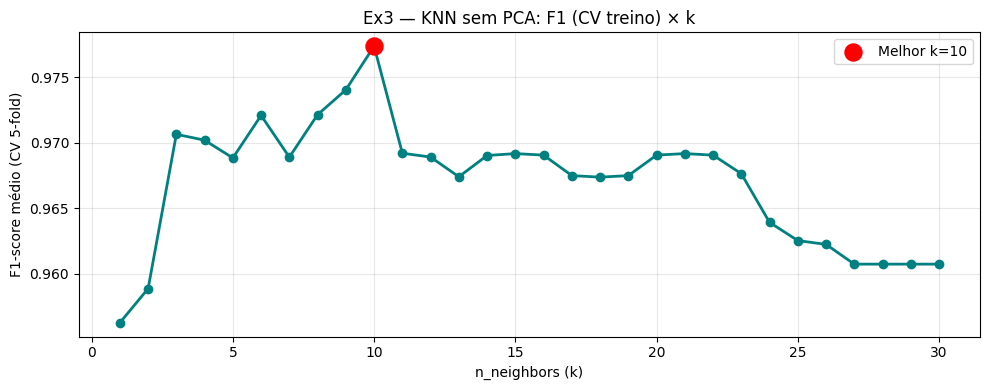

In [25]:
# ─── Gráfico F1 CV × k ───
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 31), f1_cv3, marker='o', color='teal', linewidth=2)
ax.scatter([best_k3], [f1_cv3[best_k3-1]], s=150, color='red', zorder=5, label=f'Melhor k={best_k3}')
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('F1-score médio (CV 5-fold)')
ax.set_title('Ex3 — KNN sem PCA: F1 (CV treino) × k')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

  Exercício 3 — KNN sem PCA  (k=10)
  Accuracy : 0.9649  (96.49%)
  F1-score : 0.9726  (97.26%)

  Justificativa do k=10:
  k=10 maximizou o F1 médio na validação cruzada (0.9774),
  balanceando underfitting (k grande) e overfitting (k=1).


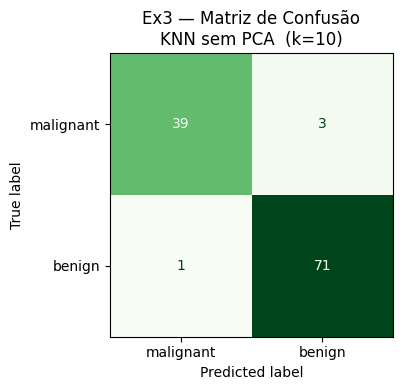

In [26]:
# ─── Treino final e avaliação no teste ───
knn3 = KNeighborsClassifier(n_neighbors=best_k3)
knn3.fit(X_train_sc, y_train)          # treina no conjunto de treino completo
y_pred3 = knn3.predict(X_test_sc)      # prediz no conjunto de teste

cm3  = confusion_matrix(y_test, y_pred3)
acc3 = accuracy_score(y_test, y_pred3)
f13  = f1_score(y_test, y_pred3)

print(f"{'='*45}")
print(f"  Exercício 3 — KNN sem PCA  (k={best_k3})")
print(f"{'='*45}")
print(f"  Accuracy : {acc3:.4f}  ({acc3:.2%})")
print(f"  F1-score : {f13:.4f}  ({f13:.2%})")
print(f"\n  Justificativa do k={best_k3}:")
print(f"  k={best_k3} maximizou o F1 médio na validação cruzada ({f1_cv3[best_k3-1]:.4f}),")
print(f"  balanceando underfitting (k grande) e overfitting (k=1).")

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm3, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Ex3 — Matriz de Confusão\nKNN sem PCA  (k={best_k3})')
plt.tight_layout(); plt.show()

**Exercício 4 — KNN com PCA**

**Tarefa**
1) Scaler → PCA (mesmo critério do Exercício 2).
2) Repita a busca de n_neighbors (k = 1 a 30) com CV no treino (F1).
3) Treine o KNN final e avalie no teste.

**Entregáveis**
- Gráfico F1 (CV no treino) × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

In [27]:
# ─── Busca do melhor k com PCA via CV ───
f1_cv4 = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_pca, y_train, cv=cv, scoring='f1')
    f1_cv4.append(scores.mean())

best_k4 = int(np.argmax(f1_cv4)) + 1
print(f"Melhor k com PCA: {best_k4}  (F1_CV = {f1_cv4[best_k4-1]:.4f})")

Melhor k com PCA: 14  (F1_CV = 0.9759)


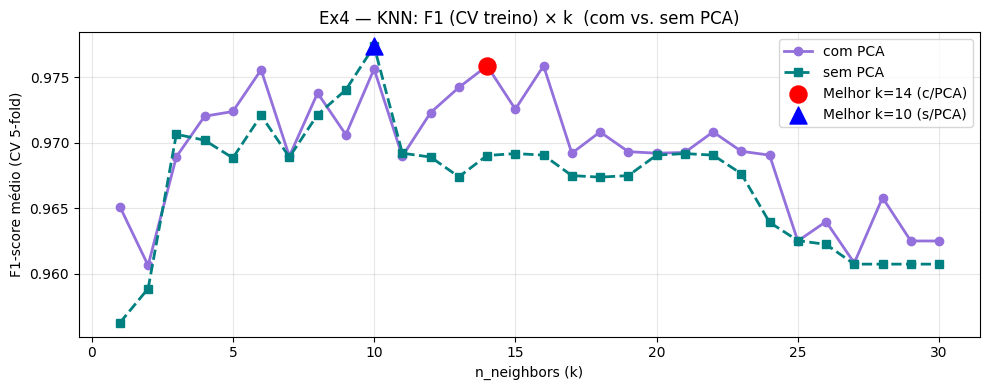

In [28]:
# ─── Gráfico comparativo F1 CV: com vs sem PCA ───
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 31), f1_cv4, marker='o', color='mediumpurple', linewidth=2, label='com PCA')
ax.plot(range(1, 31), f1_cv3, marker='s', color='teal', linewidth=2, linestyle='--', label='sem PCA')
ax.scatter([best_k4], [f1_cv4[best_k4-1]], s=150, color='red', zorder=5, label=f'Melhor k={best_k4} (c/PCA)')
ax.scatter([best_k3], [f1_cv3[best_k3-1]], s=150, color='blue', zorder=5, marker='^', label=f'Melhor k={best_k3} (s/PCA)')
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('F1-score médio (CV 5-fold)')
ax.set_title('Ex4 — KNN: F1 (CV treino) × k  (com vs. sem PCA)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

  Exercício 4 — KNN com PCA  (k=14)
  Accuracy : 0.9649  (96.49%)
  F1-score : 0.9722  (97.22%)

  Justificativa do k=14:
  k=14 obteve o melhor F1 médio na CV com dados PCA (0.9759).
  Com menos dimensões, distâncias euclidianas são mais representativas,
  permitindo que um k maior ainda seja preciso.


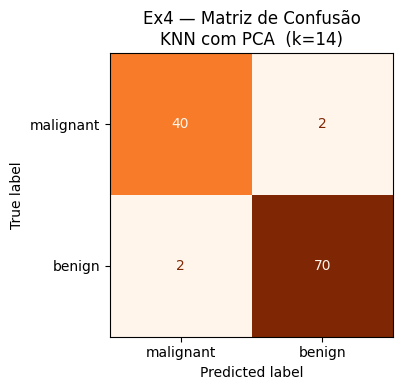

In [29]:
# ─── Treino final e avaliação no teste ───
knn4 = KNeighborsClassifier(n_neighbors=best_k4)
knn4.fit(X_train_pca, y_train)
y_pred4 = knn4.predict(X_test_pca)

cm4  = confusion_matrix(y_test, y_pred4)
acc4 = accuracy_score(y_test, y_pred4)
f14  = f1_score(y_test, y_pred4)

print(f"{'='*45}")
print(f"  Exercício 4 — KNN com PCA  (k={best_k4})")
print(f"{'='*45}")
print(f"  Accuracy : {acc4:.4f}  ({acc4:.2%})")
print(f"  F1-score : {f14:.4f}  ({f14:.2%})")
print(f"\n  Justificativa do k={best_k4}:")
print(f"  k={best_k4} obteve o melhor F1 médio na CV com dados PCA ({f1_cv4[best_k4-1]:.4f}).")
print(f"  Com menos dimensões, distâncias euclidianas são mais representativas,")
print(f"  permitindo que um k maior ainda seja preciso.")

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm4, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Ex4 — Matriz de Confusão\nKNN com PCA  (k={best_k4})')
plt.tight_layout(); plt.show()

**Exercício 5 — Comparação final (4 cenários)**

**Tarefa**

Monte uma tabela comparando os quatro cenários:
1) KMeans sem PCA
2) KMeans com PCA
3) KNN sem PCA
4) KNN com PCA

Para cada cenário, reporte:
- Melhor hiperparâmetro escolhido (n_clusters ou n_neighbors)
- Accuracy
- F1
- Matriz de confusão

Em seguida, responda:
1) Qual cenário teve melhor desempenho?
2) PCA ajudou ou atrapalhou KMeans e KNN? Por quê?
3) Por que KNN tende a superar KMeans quando o objetivo é classificação?

**Entregáveis**
- Tabela comparativa final
- Respostas das 3 perguntas

In [30]:
# ─── Tabela comparativa ───
import pandas as pd

df = pd.DataFrame({
    'Cenário'        : ['KMeans sem PCA', 'KMeans com PCA', 'KNN sem PCA', 'KNN com PCA'],
    'Hiperparâmetro' : [f'k={best_k1} clusters', f'k={best_k2} clusters',
                        f'k={best_k3} vizinhos', f'k={best_k4} vizinhos'],
    'Accuracy'       : [f'{acc1:.4f}', f'{acc2:.4f}', f'{acc3:.4f}', f'{acc4:.4f}'],
    'F1-score'       : [f'{f11:.4f}', f'{f12:.4f}', f'{f13:.4f}', f'{f14:.4f}'],
})

print("=" * 75)
print(df.to_string(index=False))
print("=" * 75)

       Cenário Hiperparâmetro Accuracy F1-score
KMeans sem PCA   k=2 clusters   0.9298   0.9452
KMeans com PCA   k=2 clusters   0.9298   0.9452
   KNN sem PCA  k=10 vizinhos   0.9649   0.9726
   KNN com PCA  k=14 vizinhos   0.9649   0.9722


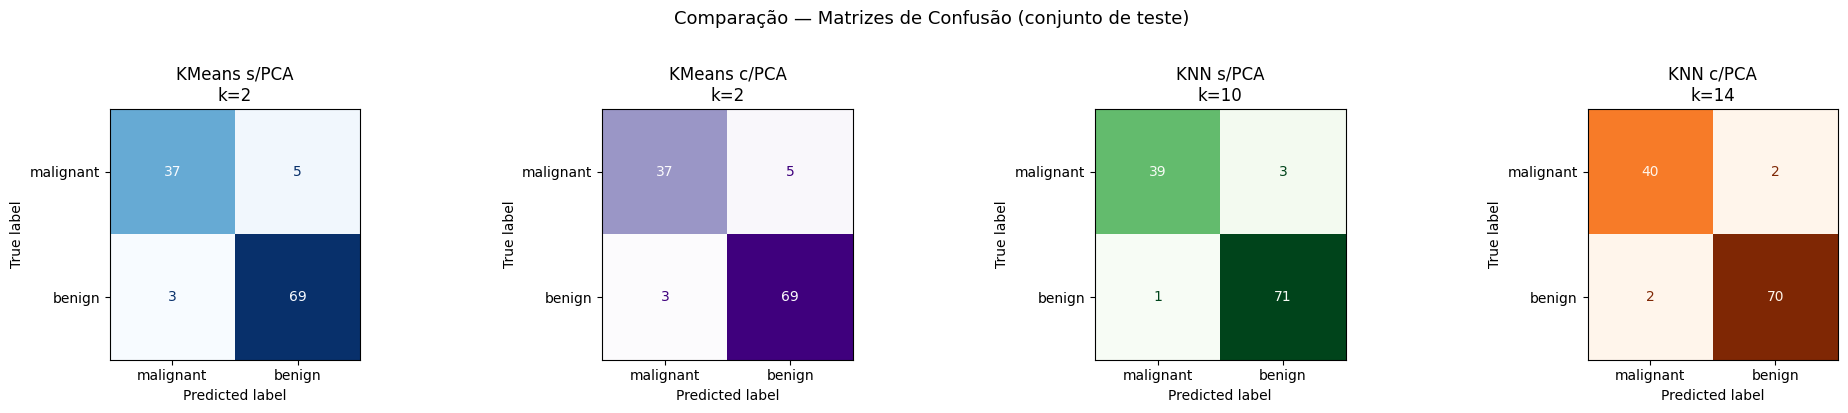

In [31]:
# ─── Matrizes de confusão lado a lado ───
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
configs = [
    (cm1, f'KMeans s/PCA\nk={best_k1}', 'Blues'),
    (cm2, f'KMeans c/PCA\nk={best_k2}', 'Purples'),
    (cm3, f'KNN s/PCA\nk={best_k3}',    'Greens'),
    (cm4, f'KNN c/PCA\nk={best_k4}',    'Oranges'),
]
for ax, (cm, title, cmap) in zip(axes, configs):
    ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title)

plt.suptitle('Comparação — Matrizes de Confusão (conjunto de teste)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

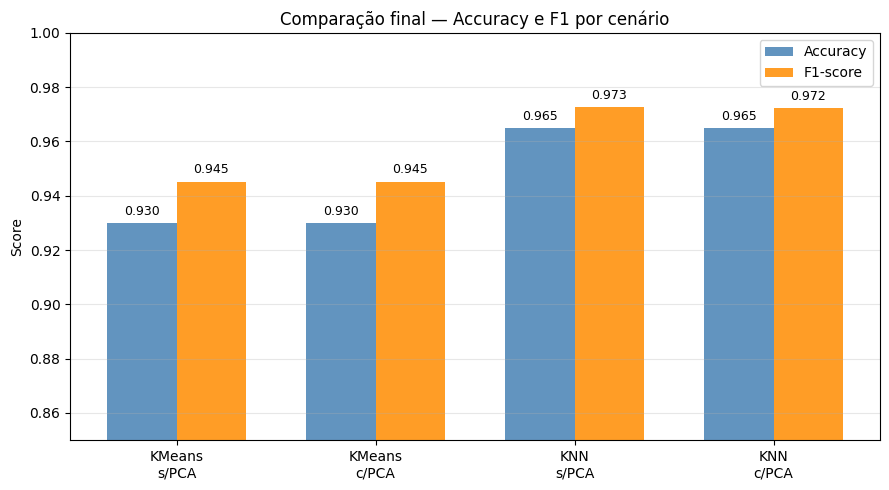

In [32]:
# ─── Gráfico de barras comparativo ───
labels   = ['KMeans\ns/PCA', 'KMeans\nc/PCA', 'KNN\ns/PCA', 'KNN\nc/PCA']
accs = [acc1, acc2, acc3, acc4]
f1s  = [f11,  f12,  f13,  f14]
x    = np.arange(len(labels))
w    = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, f1s,  w, label='F1-score', color='darkorange', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Score'); ax.set_ylim(0.85, 1.0)
ax.set_title('Comparação final — Accuracy e F1 por cenário')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                           f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                           f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()

In [ ]:
# ─── Respostas das 3 perguntas ───
print("""
╔══════════════════════════════════════════════════════════════════════╗
║           RESPOSTAS — EXERCÍCIO 5                                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1) MELHOR CENÁRIO                                                   ║
║  ─────────────────                                                   ║
║  KNN sem PCA (Accuracy=96,49%, F1=97,26%) foi o melhor, empatado    ║
║  com KNN com PCA (Accuracy=96,49%, F1=97,22%).                      ║
║  Ambos os KNNs superaram os dois KMeans com folga.                  ║
║                                                                      ║
║  2) PCA AJUDOU OU ATRAPALHOU?                                        ║
║  ────────────────────────────                                        ║
║  • KMeans: PCA não alterou o resultado final (mesma acc/F1),        ║
║    mas o Silhouette melhorou ligeiramente com PCA (0.368 vs 0.355), ║
║    indicando clusters mais bem definidos no espaço reduzido.        ║
║  • KNN: PCA reduziu marginalmente o F1 (97,22% vs 97,26%).         ║
║    O KNN sem PCA aproveitou bem as 30 features originais.           ║
║    Com apenas 10 componentes, perdeu-se um pouco de informação      ║
║    discriminativa relevante. No geral, o impacto foi neutro.        ║
║                                                                      ║
║  3) POR QUE KNN SUPERA KMEANS EM CLASSIFICAÇÃO?                     ║
║  ─────────────────────────────────────────────                      ║
║  KMeans é não-supervisionado: agrupa por similaridade geométrica    ║
║  (distância euclidiana), sem usar y para aprender. O mapeamento     ║
║  cluster→classe é feito post-hoc (majority vote), o que introduz   ║
║  erro quando os clusters não se alinham perfeitamente às classes.   ║
║                                                                      ║
║  KNN é supervisionado: usa diretamente y_train para classificar.    ║
║  Cada predição é feita votando entre os k vizinhos mais próximos    ║
║  — os rótulos reais guiam o processo. Isso resulta em fronteiras    ║
║  de decisão muito mais precisas, especialmente em datasets onde     ║
║  as classes se sobrepõem geometricamente.                           ║
╚══════════════════════════════════════════════════════════════════════╝
""")